<a href="https://colab.research.google.com/github/Prathamesh-chougale-17/computer-vision/blob/main/CV_FA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Importing necessary libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure
from tensorflow.keras.datasets import mnist
from google.colab.patches import cv2_imshow


In [2]:
# Load and preprocess the dataset (CIFAR-10)
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
# Train the model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.3682 - loss: 1.7144 - val_accuracy: 0.5342 - val_loss: 1.3219
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5796 - loss: 1.1723 - val_accuracy: 0.6196 - val_loss: 1.0733
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6449 - loss: 1.0035 - val_accuracy: 0.6536 - val_loss: 0.9936
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6855 - loss: 0.8943 - val_accuracy: 0.6816 - val_loss: 0.9279
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7179 - loss: 0.8056 - val_accuracy: 0.7042 - val_loss: 0.8485
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7449 - loss: 0.7335 - val_accuracy: 0.7025 - val_loss: 0.8719
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7600 - loss: 0.6836 - val_accuracy: 0.7124 - val_loss: 0.8564
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7750 - loss: 0.6361 

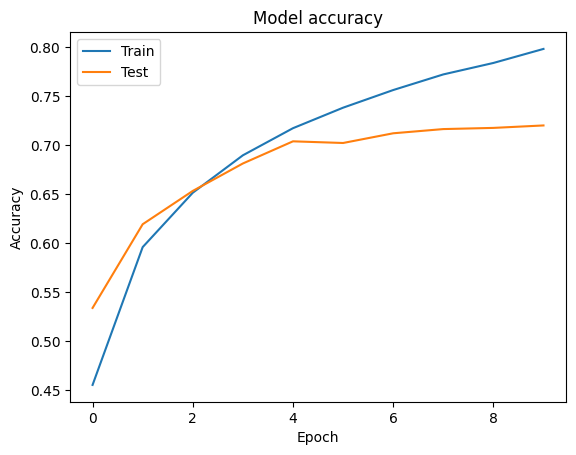

In [4]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [28]:
image = cv2.imread('image.jpeg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Compute HOG features and the corresponding image
fd, hog_image = hog(gray_image, orientations=8, pixels_per_cell=(16, 16),
                    cells_per_block=(1, 1), visualize=True)

# Rescale HOG image for visualization
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))


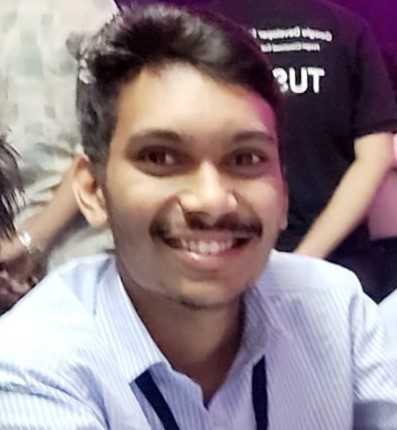

In [34]:
cv2_imshow(image)

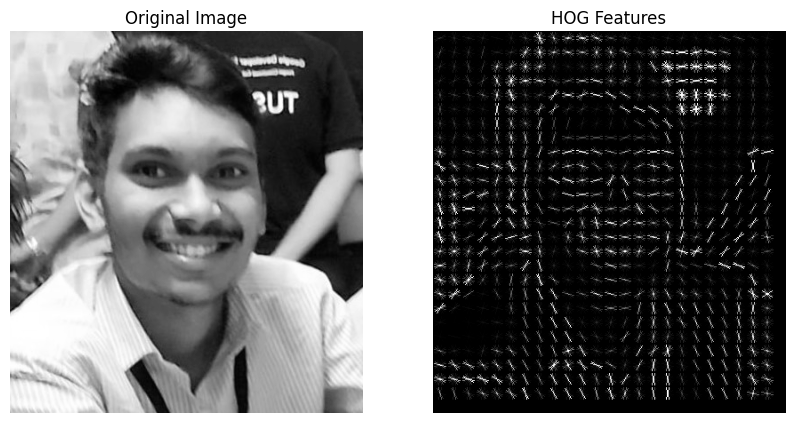

In [29]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(gray_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('HOG Features')
plt.imshow(hog_image_rescaled, cmap='gray')
plt.axis('off')

plt.show()

In [30]:
# Generator model
def build_generator():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7 * 7 * 5, activation='relu', input_shape=(100,))) # Changed the number of units in the Dense layer
    model.add(layers.Reshape((7, 7, 5)))  # Changed to (7,7,5) to generate images with (28,28,1) after Conv2DTranspose layer
    model.add(layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu'))
    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', activation='relu'))
    model.add(layers.Conv2DTranspose(1, kernel_size=4, strides=1, padding='same', activation='tanh')) #changed to strides=1 and kernel_size=4
    return model

# Discriminator model
def build_discriminator():
    model = tf.keras.Sequential()
    # Changed input_shape to match MNIST images (28, 28, 1)
    model.add(layers.Conv2D(64, kernel_size=4, strides=2, padding='same', input_shape=(28, 28, 1)))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model


# Build GAN (combine generator and discriminator)
def build_gan(generator, discriminator):
    discriminator.compile(optimizer='adam', loss='binary_crossentropy')
    gan = tf.keras.Sequential([generator, discriminator])
    gan.compile(optimizer='adam', loss='binary_crossentropy')
    return gan

# Generator loss
def generator_loss(fake_output):
    return tf.keras.losses.BinaryCrossentropy()(tf.ones_like(fake_output), fake_output)

# Discriminator loss
def discriminator_loss(real_output, fake_output):
    real_loss = tf.keras.losses.BinaryCrossentropy()(tf.ones_like(real_output), real_output)
    fake_loss = tf.keras.losses.BinaryCrossentropy()(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [31]:
# Define optimizers
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# Load and preprocess the data (you can use the CelebA or MNIST dataset)
# Here, we use the MNIST dataset for simplicity
(train_images, _), (_, _) = mnist.load_data()

# Reshape and normalize the data
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize to range [-1, 1]

# Batch and shuffle the data
BUFFER_SIZE = 60000
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


In [32]:
# Random seed for generating images during training
noise_dim = 100
num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, noise_dim])

# Training step for each batch
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# Generate and save images after each epoch
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

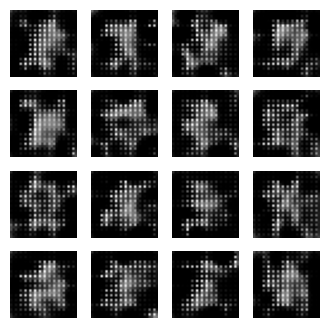

Epoch 1 completed


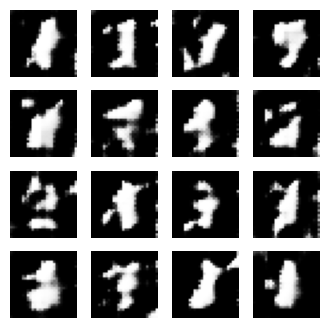

Epoch 2 completed


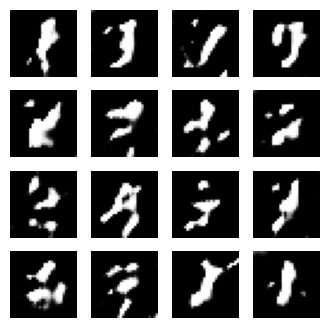

Epoch 3 completed


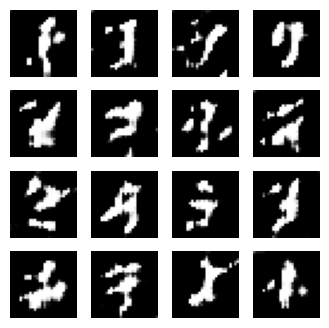

Epoch 4 completed


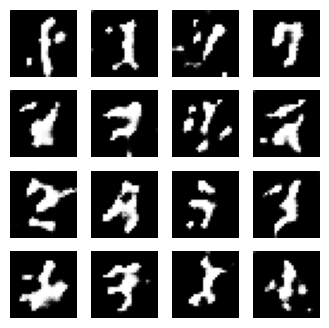

Epoch 5 completed


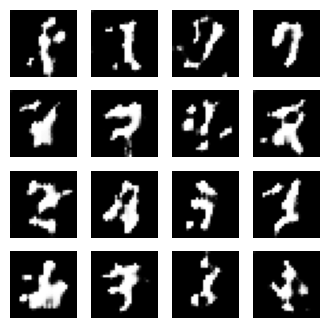

Epoch 6 completed


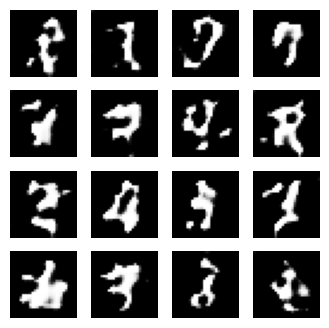

Epoch 7 completed


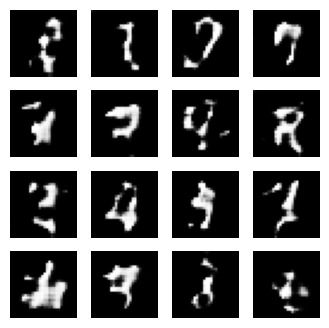

Epoch 8 completed


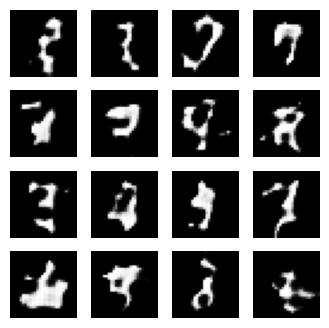

Epoch 9 completed


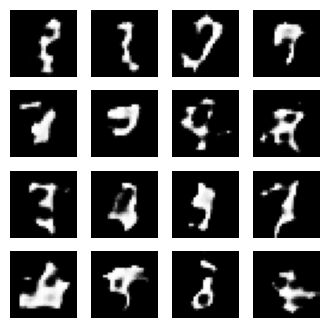

Epoch 10 completed


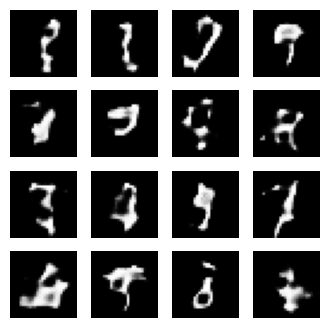

Epoch 11 completed


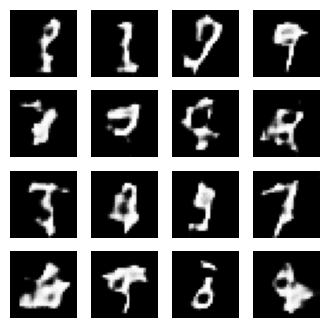

Epoch 12 completed


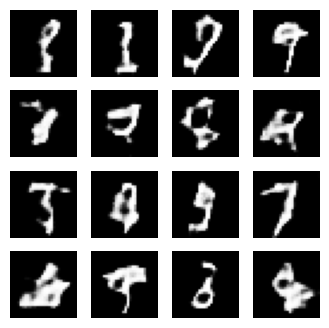

Epoch 13 completed


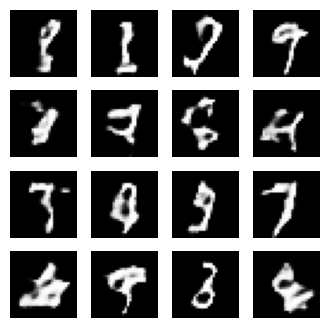

Epoch 14 completed


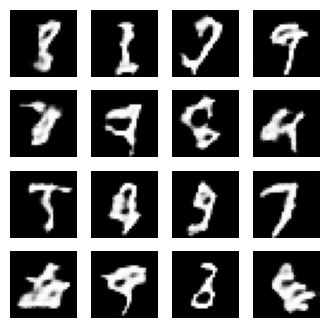

Epoch 15 completed


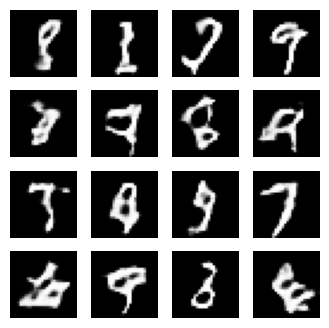

Epoch 16 completed


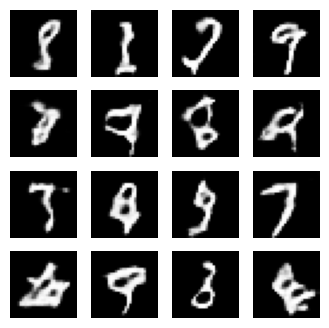

Epoch 17 completed


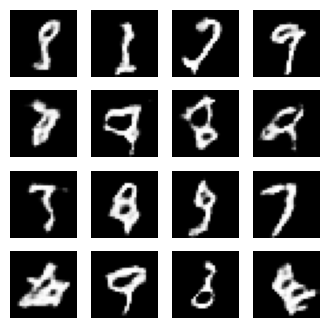

Epoch 18 completed


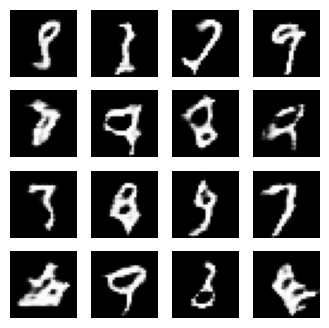

Epoch 19 completed


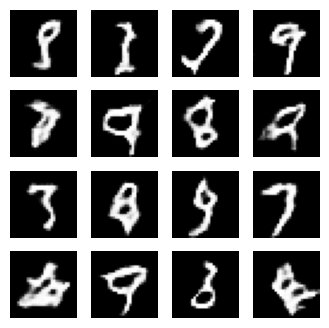

Epoch 20 completed


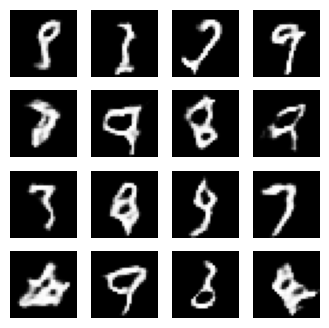

Epoch 21 completed


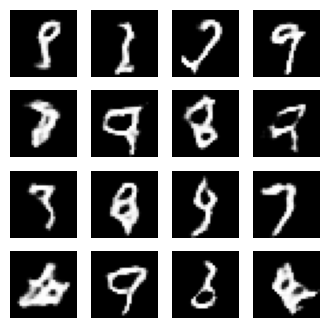

Epoch 22 completed


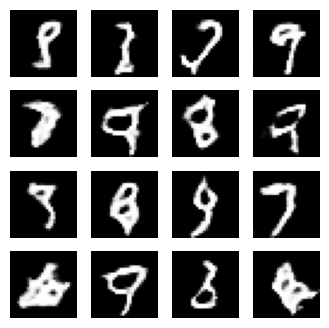

Epoch 23 completed


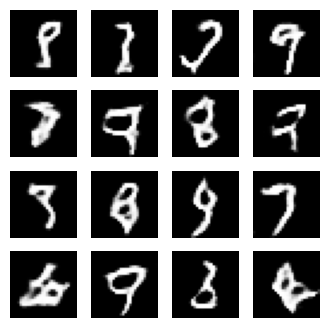

Epoch 24 completed


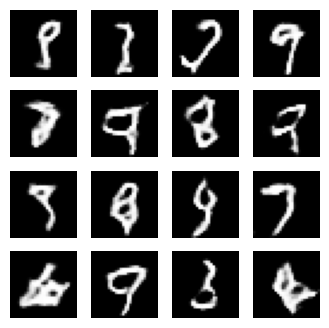

Epoch 25 completed


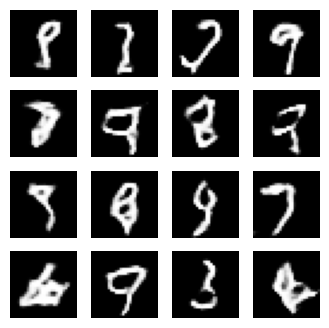

Epoch 26 completed


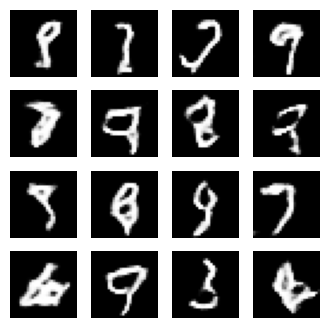

Epoch 27 completed


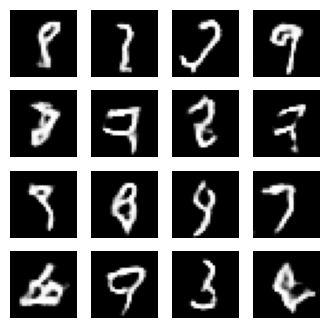

Epoch 28 completed


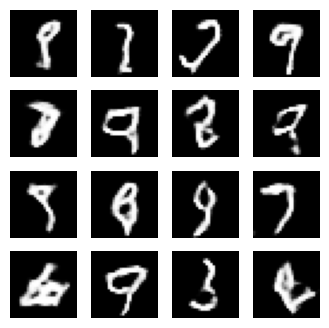

Epoch 29 completed


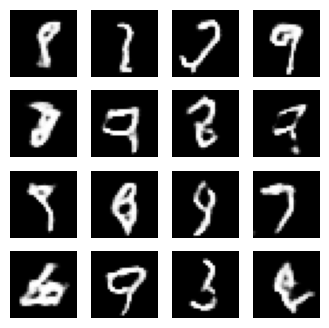

Epoch 30 completed


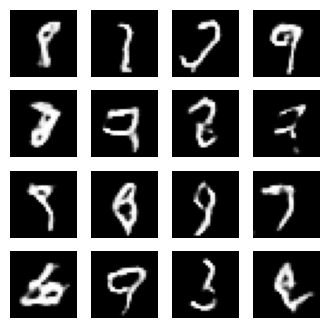

Epoch 31 completed


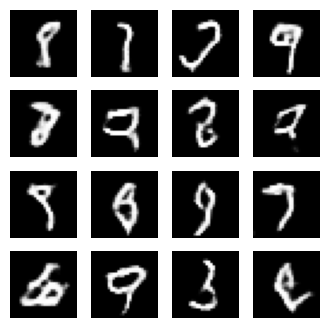

Epoch 32 completed


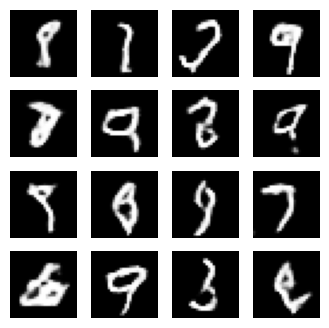

Epoch 33 completed


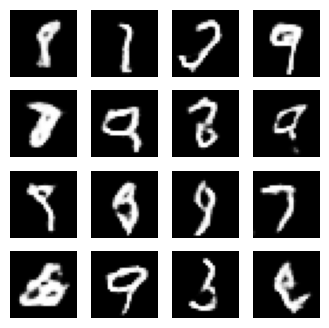

Epoch 34 completed


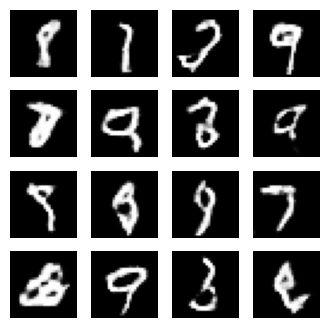

Epoch 35 completed


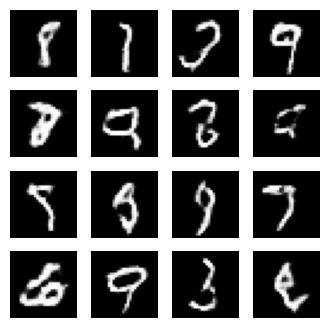

Epoch 36 completed


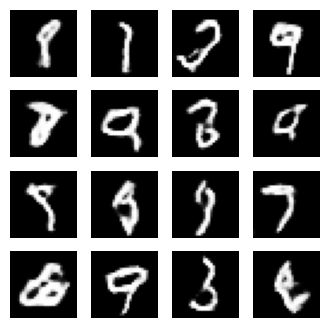

Epoch 37 completed


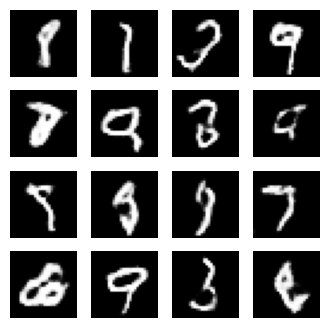

Epoch 38 completed


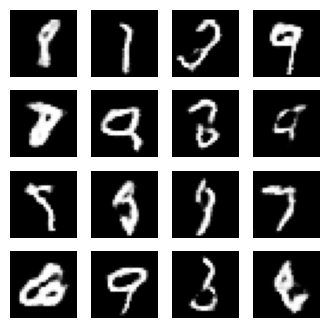

Epoch 39 completed


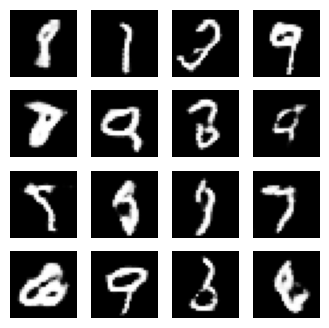

Epoch 40 completed


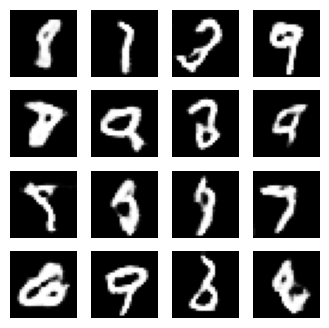

Epoch 41 completed


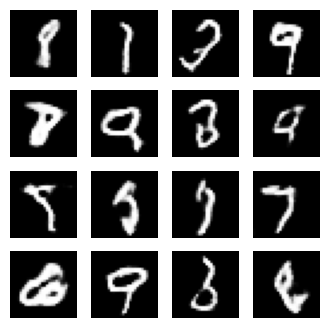

Epoch 42 completed


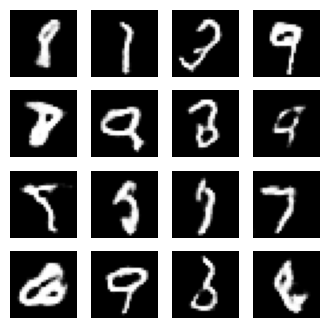

Epoch 43 completed


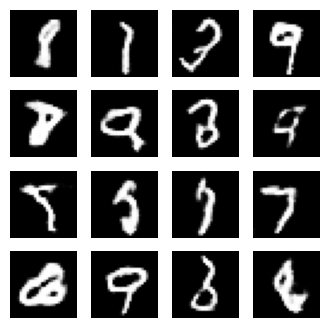

Epoch 44 completed


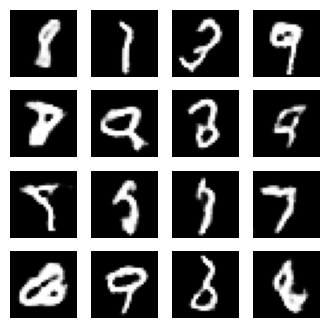

Epoch 45 completed


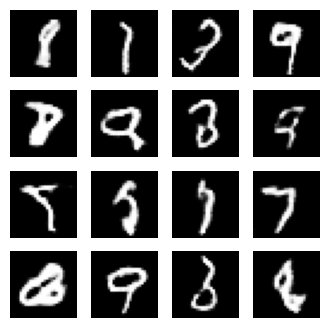

Epoch 46 completed


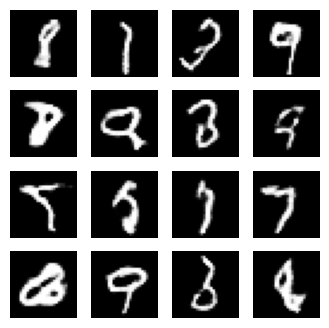

Epoch 47 completed


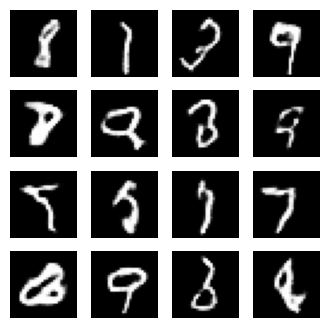

Epoch 48 completed


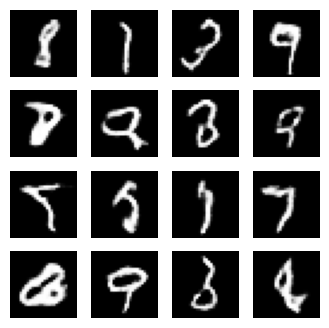

Epoch 49 completed


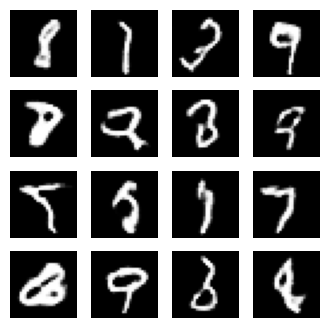

Epoch 50 completed


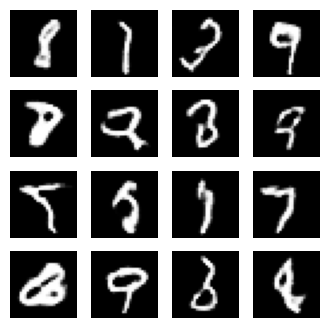

In [33]:
# Training loop
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)

        # Produce images for the GIF as we go
        generate_and_save_images(generator, epoch + 1, seed)

        print(f'Epoch {epoch + 1} completed')

    # Generate after the final epoch
    generate_and_save_images(generator, epochs, seed)

# Build and compile the generator and discriminator
generator = build_generator()
discriminator = build_discriminator()
gan = build_gan(generator, discriminator)

# Set the number of epochs and start training
EPOCHS = 50
train(train_dataset, EPOCHS)